# 🍽️ Campus Mess Food Rating System
## Data Science Analysis — EDA · Sentiment Analysis · ML Models

**Project Goal:** Analyse student food ratings to uncover quality trends, detect sentiment patterns in comments, predict future ratings, and recommend improvements to the mess committee.

---
### Project Structure
| Section | Techniques Used |
|---|---|
| 1. Data Generation & Setup | Pandas, NumPy |
| 2. Exploratory Data Analysis | Matplotlib, Seaborn |
| 3. Sentiment Analysis | TextBlob, Rule-based NLP |
| 4. Rating Prediction Model | Random Forest, Linear Regression |
| 5. Food Recommender System | Collaborative Filtering |
| 6. Insights & Recommendations | Statistical Summary |


## Section 1 — Data Generation & Setup

In [6]:
import sys
!"{sys.executable}" -m pip install textblob  

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import sys
!"{sys.executable}" -m textblob.download_corpora

Finished.


[nltk_data] Downloading package brown to C:\Users\MY
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\MY
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\MY
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\MY PC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to C:\Users\MY
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to C:\Users\MY
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [9]:

import sqlite3, pandas as pd

conn = sqlite3.connect("../mess_ratings.db")   # adjust path if needed
df = pd.read_sql("SELECT * FROM ratings", conn)
conn.close()

print(f"Loaded {len(df)} real ratings from the database!")
df.head()


DatabaseError: Execution failed on sql 'SELECT * FROM ratings': no such table: ratings

## Section 2 — Exploratory Data Analysis (EDA)

In [ ]:

# ─── Basic statistics ───────────────────────────────────
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(df.describe())
print()
print("Rating Distribution:")
print(df['rating'].value_counts().sort_index())


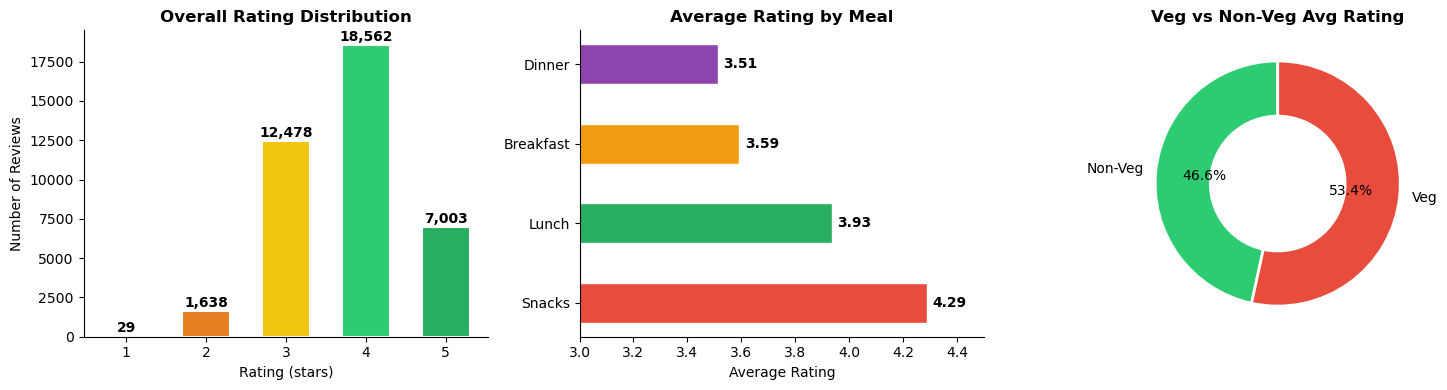

Fig 1 saved.


In [4]:

# ─── Figure 1: Overall rating distribution ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution
rating_counts = df['rating'].value_counts().sort_index()
colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#27AE60']
bars = axes[0].bar(rating_counts.index, rating_counts.values, color=colors, width=0.6, edgecolor='white', linewidth=1.5)
axes[0].set_title('Overall Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Number of Reviews')
for bar, count in zip(bars, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Meal-wise avg rating
meal_avg = df.groupby('meal')['rating'].mean().sort_values(ascending=False)
meal_colors = {'Breakfast': '#F39C12', 'Lunch': '#27AE60', 'Dinner': '#8E44AD', 'Snacks': '#E74C3C'}
axes[1].barh(meal_avg.index, meal_avg.values,
             color=[meal_colors[m] for m in meal_avg.index], height=0.5, edgecolor='white')
axes[1].set_xlim(3, 4.5)
axes[1].set_title('Average Rating by Meal', fontweight='bold')
axes[1].set_xlabel('Average Rating')
for i, (meal, val) in enumerate(meal_avg.items()):
    axes[1].text(val + 0.02, i, f'{val:.2f}', va='center', fontweight='bold')

# Category comparison
cat_data = df.groupby('category')['rating'].mean()
wedge_props = dict(width=0.45, edgecolor='white', linewidth=2)
axes[2].pie(cat_data.values, labels=cat_data.index, autopct='%1.1f%%',
            colors=['#2ECC71', '#E74C3C'], wedgeprops=wedge_props, startangle=90)
axes[2].set_title('Veg vs Non-Veg Avg Rating', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 saved.")


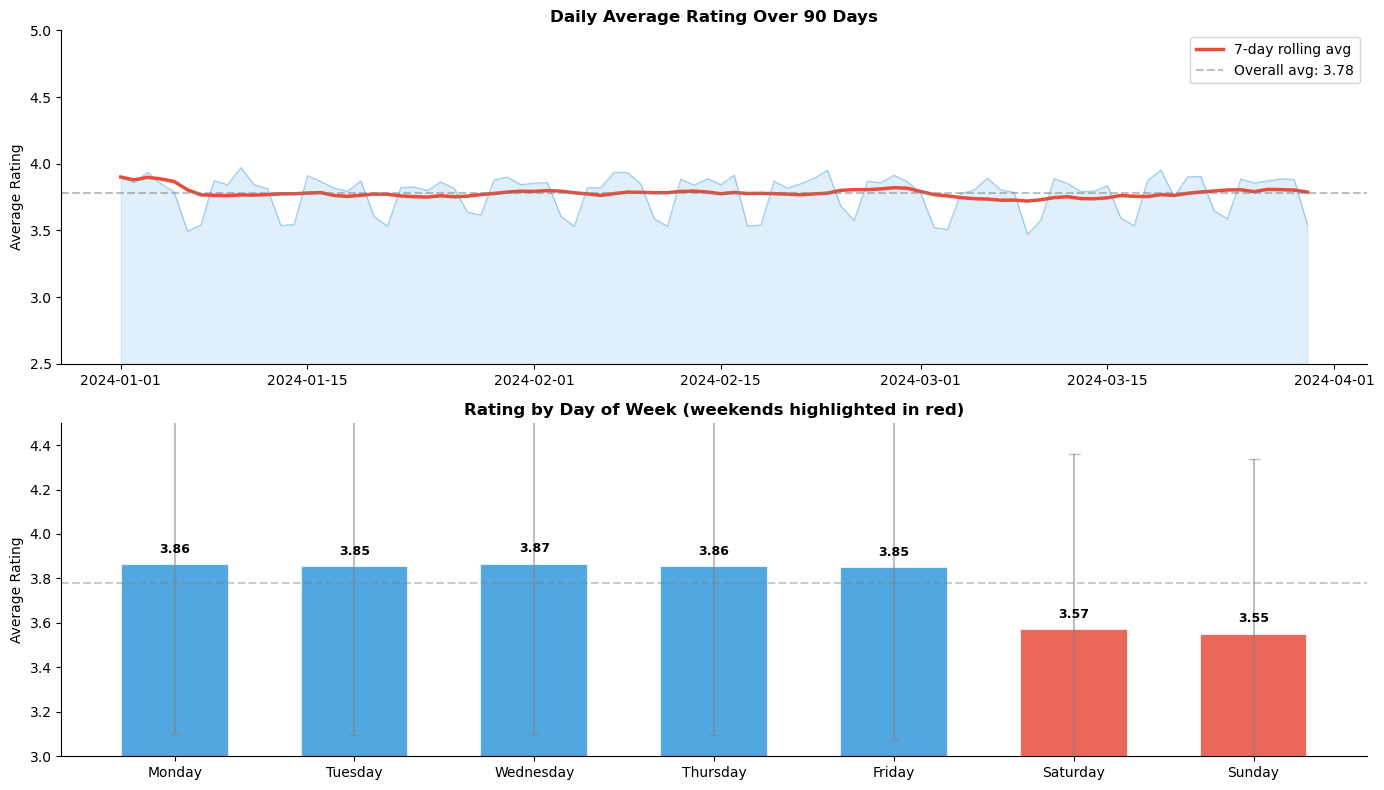

Fig 2 saved.


In [5]:

# ─── Figure 2: Time series & weekly trends ─────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily trend
daily = df.groupby('date')['rating'].mean().reset_index()
daily['rolling7'] = daily['rating'].rolling(7, min_periods=1).mean()
axes[0].fill_between(daily['date'], daily['rating'], alpha=0.15, color='#3498DB')
axes[0].plot(daily['date'], daily['rating'], color='#3498DB', alpha=0.4, linewidth=0.8)
axes[0].plot(daily['date'], daily['rolling7'], color='#E74C3C', linewidth=2.5, label='7-day rolling avg')
axes[0].axhline(df['rating'].mean(), color='gray', linestyle='--', alpha=0.5, label=f'Overall avg: {df["rating"].mean():.2f}')
axes[0].set_title('Daily Average Rating Over 90 Days', fontweight='bold')
axes[0].set_ylabel('Average Rating')
axes[0].legend()
axes[0].set_ylim(2.5, 5)

# Day-of-week pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('day')['rating'].mean().reindex(dow_order)
dow_std = df.groupby('day')['rating'].std().reindex(dow_order)
bar_colors = ['#3498DB'] * 5 + ['#E74C3C'] * 2  # weekdays blue, weekend red
bars = axes[1].bar(dow_avg.index, dow_avg.values, yerr=dow_std.values,
                   color=bar_colors, alpha=0.85, width=0.6,
                   error_kw=dict(ecolor='gray', capsize=4, alpha=0.5),
                   edgecolor='white', linewidth=1.5)
axes[1].set_ylim(3.0, 4.5)
axes[1].set_title('Rating by Day of Week (weekends highlighted in red)', fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].axhline(df['rating'].mean(), color='gray', linestyle='--', alpha=0.4)
for bar, val in zip(bars, dow_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 2 saved.")


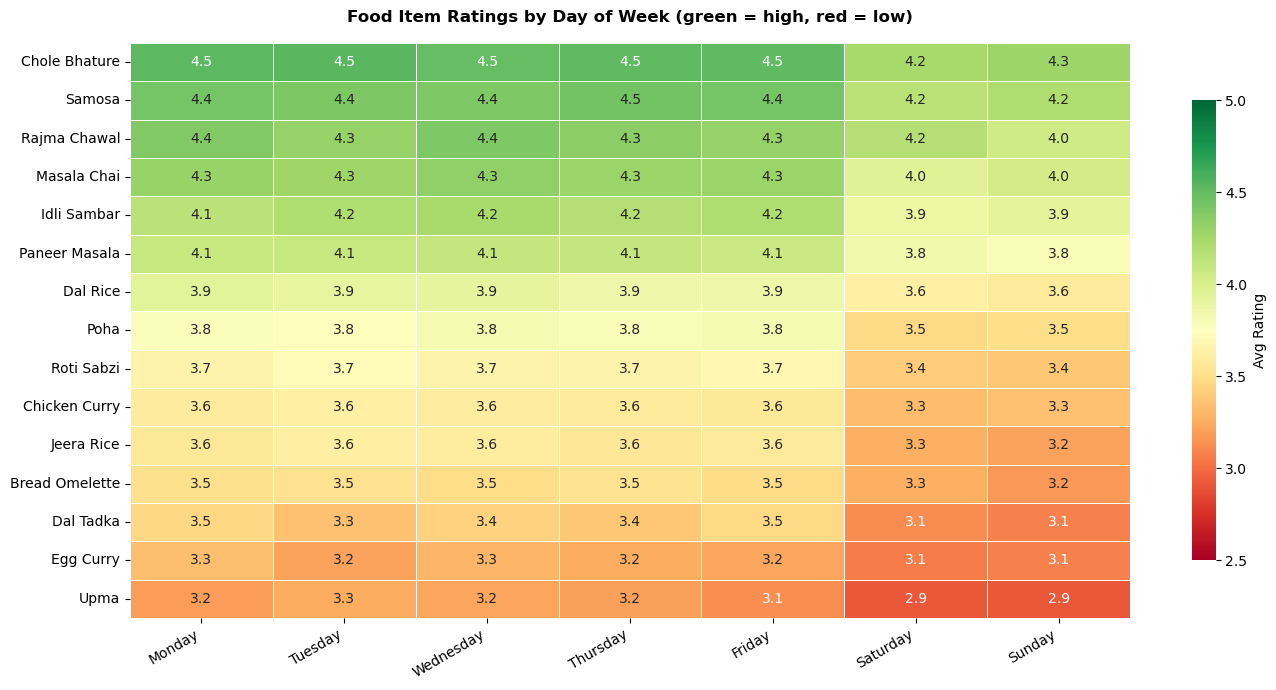

Fig 3 saved.


In [8]:

# ─── Figure 3: Food item heatmap ───────────────────────
pivot = df.groupby(['food_item', 'day'])['rating'].mean().unstack(fill_value=3)

pivot = pivot.reindex(columns=dow_order)

# Sort food items by average rating
pivot['avg'] = pivot.mean(axis=1)

pivot = pivot.sort_values('avg', ascending=False).drop('avg', axis=1)

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='RdYlGn',
    vmin=2.5,
    vmax=5.0,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg Rating', 'shrink': 0.8}
)

ax.set_title(
    'Food Item Ratings by Day of Week (green = high, red = low)',
    fontweight='bold',
    pad=15
)

ax.set_xlabel('')
ax.set_ylabel('')

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig('fig3_heatmap.png', dpi=150, bbox_inches='tight')

plt.show()

print("Fig 3 saved.")


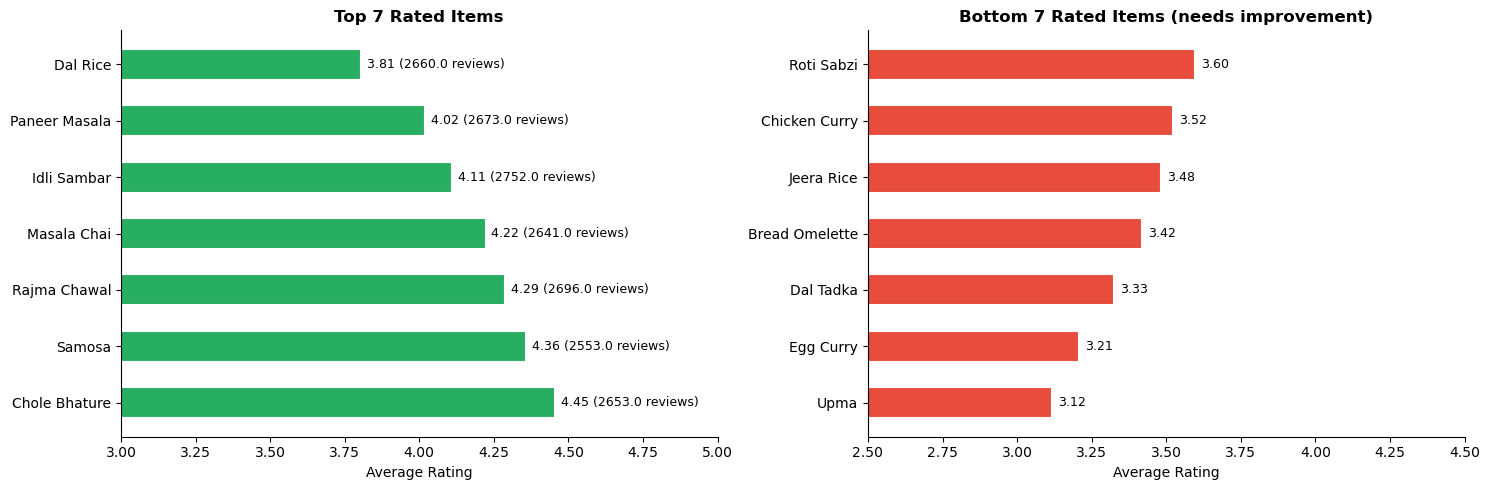

Fig 4 saved.


In [9]:

# ─── Figure 4: Top/Bottom items + hostel comparison ────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

item_stats = df.groupby('food_item').agg(
    avg_rating=('rating', 'mean'),
    count=('rating', 'count'),
    std=('rating', 'std')
).sort_values('avg_rating', ascending=False)

# Top 7 vs Bottom 7
top7    = item_stats.head(7)
bottom7 = item_stats.tail(7).sort_values('avg_rating')

axes[0].barh(top7.index, top7['avg_rating'],
             color='#27AE60', height=0.55, edgecolor='white', linewidth=1.5)
axes[0].set_xlim(3.0, 5.0)
axes[0].set_title('Top 7 Rated Items', fontweight='bold')
axes[0].set_xlabel('Average Rating')
for i, (item, row) in enumerate(top7.iterrows()):
    axes[0].text(row['avg_rating'] + 0.02, i, f'{row["avg_rating"]:.2f} ({row["count"]} reviews)',
                 va='center', fontsize=9)

axes[1].barh(bottom7.index, bottom7['avg_rating'],
             color='#E74C3C', height=0.55, edgecolor='white', linewidth=1.5)
axes[1].set_xlim(2.5, 4.5)
axes[1].set_title('Bottom 7 Rated Items (needs improvement)', fontweight='bold')
axes[1].set_xlabel('Average Rating')
for i, (item, row) in enumerate(bottom7.iterrows()):
    axes[1].text(row['avg_rating'] + 0.02, i, f'{row["avg_rating"]:.2f}',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_rankings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 4 saved.")


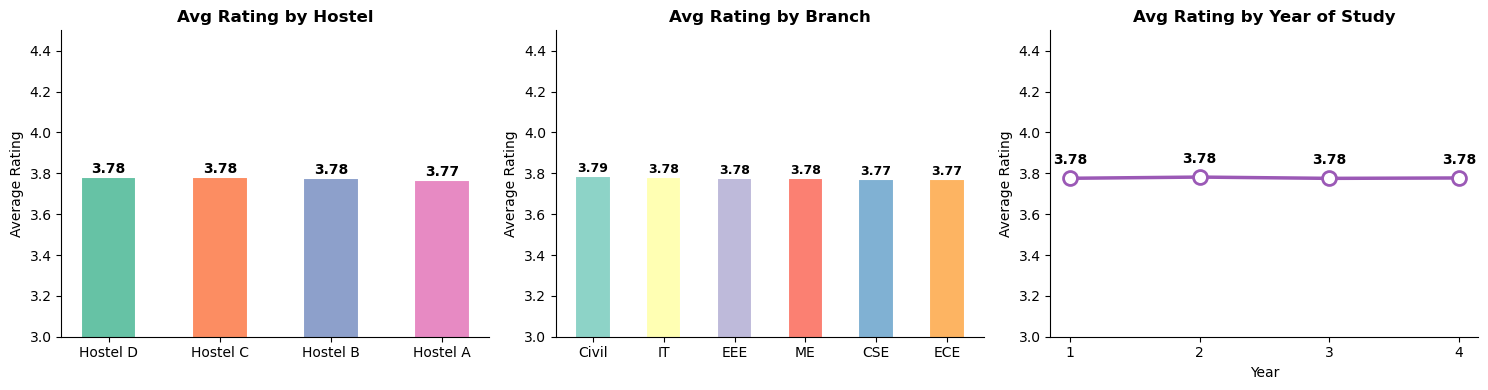

Fig 5 saved.


In [10]:

# ─── Figure 5: Student demographics ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hostel comparison
hostel_avg = df.groupby('hostel')['rating'].mean().sort_values(ascending=False)
axes[0].bar(hostel_avg.index, hostel_avg.values,
            color=sns.color_palette("Set2", len(hostel_avg)),
            edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_ylim(3.0, 4.5)
axes[0].set_title('Avg Rating by Hostel', fontweight='bold')
axes[0].set_ylabel('Average Rating')
for i, (h, v) in enumerate(hostel_avg.items()):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Branch comparison
branch_avg = df.groupby('branch')['rating'].mean().sort_values(ascending=False)
axes[1].bar(branch_avg.index, branch_avg.values,
            color=sns.color_palette("Set3", len(branch_avg)),
            edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_ylim(3.0, 4.5)
axes[1].set_title('Avg Rating by Branch', fontweight='bold')
axes[1].set_ylabel('Average Rating')
for i, (b, v) in enumerate(branch_avg.items()):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Year comparison
year_avg = df.groupby('year')['rating'].mean()
axes[2].plot(year_avg.index, year_avg.values, 'o-',
             color='#9B59B6', linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2)
axes[2].set_ylim(3.0, 4.5)
axes[2].set_title('Avg Rating by Year of Study', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Average Rating')
axes[2].set_xticks([1, 2, 3, 4])
for yr, val in year_avg.items():
    axes[2].annotate(f'{val:.2f}', (yr, val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 5 saved.")


## Section 3 — Sentiment Analysis on Comments

We use **TextBlob** to extract polarity scores from student comments, then compare sentiment with star ratings to validate data consistency and catch cases where text sentiment doesn't match the star rating (potential sarcasm or data quality issues).


In [11]:

# ─── Sentiment scoring ─────────────────────────────────
def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity  # -1 to +1
    if polarity > 0.2:   return 'Positive', polarity
    elif polarity < -0.1: return 'Negative', polarity
    else:                 return 'Neutral',  polarity

df[['sentiment_label', 'sentiment_score']] = df['comment'].apply(
    lambda c: pd.Series(get_sentiment(c))
)

print("Sentiment Distribution:")
print(df['sentiment_label'].value_counts())
print()
print("Average sentiment score by star rating:")
print(df.groupby('rating')['sentiment_score'].mean().round(3))


Sentiment Distribution:
sentiment_label
Positive    26778
Negative     6973
Neutral      5959
Name: count, dtype: int64

Average sentiment score by star rating:
rating
1   -0.685
2   -0.094
3    0.255
4    0.360
5    0.707
Name: sentiment_score, dtype: float64


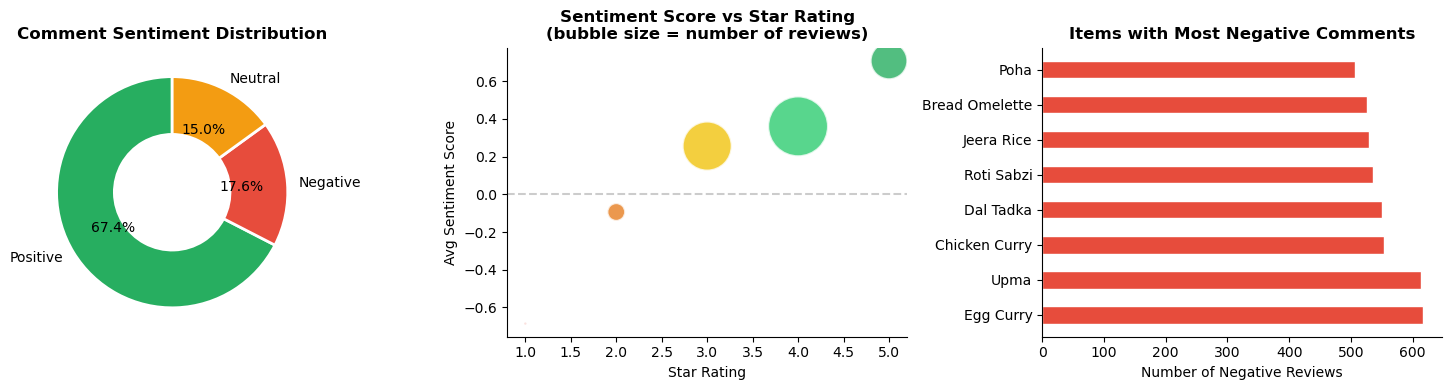

Fig 6 saved.


In [13]:

# ─── Figure 6: Sentiment analysis plots ────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sentiment distribution pie
sent_counts = df['sentiment_label'].value_counts()

sent_colors = {
    'Positive': '#27AE60',
    'Neutral': '#F39C12',
    'Negative': '#E74C3C'
}

axes[0].pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct='%1.1f%%',
    colors=[sent_colors[s] for s in sent_counts.index],
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    startangle=90
)

axes[0].set_title(
    'Comment Sentiment Distribution',
    fontweight='bold'
)

# Sentiment score vs star rating (scatter)

scatter_data = df.groupby('rating').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    count=('rating', 'count')
).reset_index()

scatter = axes[1].scatter(
    scatter_data['rating'],
    scatter_data['avg_sentiment'],
    s=scatter_data['count'] / 10,
    alpha=0.8,
    c=['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#27AE60'],
    edgecolors='white',
    linewidth=1.5
)

axes[1].axhline(
    0,
    color='gray',
    linestyle='--',
    alpha=0.4
)

axes[1].set_title(
    'Sentiment Score vs Star Rating\n(bubble size = number of reviews)',
    fontweight='bold'
)

axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Avg Sentiment Score')

# Top negative items (needs attention)

neg_items = (
    df[df['sentiment_label'] == 'Negative']
    .groupby('food_item')['rating']
    .count()
    .sort_values(ascending=False)
    .head(8)
)

axes[2].barh(
    neg_items.index,
    neg_items.values,
    color='#E74C3C',
    height=0.5,
    edgecolor='white'
)

axes[2].set_title(
    'Items with Most Negative Comments',
    fontweight='bold'
)

axes[2].set_xlabel('Number of Negative Reviews')

plt.tight_layout()

plt.savefig(
    'fig6_sentiment.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Fig 6 saved.")

In [14]:

# ─── Mismatch detection: high stars but negative text ──
mismatch = df[(df['rating'] >= 4) & (df['sentiment_label'] == 'Negative')]
print(f"⚠️  Mismatch detected: {len(mismatch)} reviews with 4-5 stars but negative comment text")
print()
print("Sample mismatches (data quality insight):")
print(mismatch[['food_item', 'rating', 'comment', 'sentiment_score']].head(5).to_string(index=False))


⚠️  Mismatch detected: 3720 reviews with 4-5 stars but negative comment text

Sample mismatches (data quality insight):
  food_item  rating                                    comment  sentiment_score
Idli Sambar       4 Tasty as usual, slight improvement needed.        -0.208333
Idli Sambar       4 Tasty as usual, slight improvement needed.        -0.208333
Idli Sambar       4 Tasty as usual, slight improvement needed.        -0.208333
       Poha       4 Tasty as usual, slight improvement needed.        -0.208333
       Poha       4 Tasty as usual, slight improvement needed.        -0.208333


## Section 4 — Rating Prediction Model

**Goal:** Can we predict a food item's next-day rating based on historical patterns? This helps the mess committee forecast which items need quality attention before student complaints arise.

**Features used:** meal type, food category, day of week, week number, rolling avg, sentiment.


In [15]:

# ─── Feature engineering ───────────────────────────────
le = LabelEncoder()

df_ml = df.copy()
df_ml['meal_enc']     = le.fit_transform(df_ml['meal'])
df_ml['category_enc'] = le.fit_transform(df_ml['category'])
df_ml['day_enc']      = le.fit_transform(df_ml['day'])
df_ml['item_enc']     = le.fit_transform(df_ml['food_item'])
df_ml['is_weekend']   = df_ml['day'].isin(['Saturday', 'Sunday']).astype(int)
df_ml['year_enc']     = df_ml['year']

# Rolling features per food item
df_ml = df_ml.sort_values('date')
df_ml['roll_avg_7'] = df_ml.groupby('food_item')['rating'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)
df_ml['roll_avg_7'] = df_ml['roll_avg_7'].fillna(df_ml['rating'].mean())

features = ['meal_enc', 'category_enc', 'day_enc', 'item_enc',
            'is_weekend', 'week', 'roll_avg_7', 'sentiment_score', 'year_enc']

X = df_ml[features].fillna(0)
y = df_ml['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Features         : {features}")


Training samples : 31,768
Test samples     : 7,942
Features         : ['meal_enc', 'category_enc', 'day_enc', 'item_enc', 'is_weekend', 'week', 'roll_avg_7', 'sentiment_score', 'year_enc']


In [17]:

# ─── Train multiple models & compare ──────────────────
models = {
    'Linear Regression':      LinearRegression(),
    'Random Forest':          RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    cv   = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    results[name] = {'model': model, 'MAE': mae, 'R2': r2, 'CV_MAE': -cv.mean()}
    print(f"{name:25s} | MAE: {mae:.4f} | R²: {r2:.4f} | CV MAE: {-cv.mean():.4f}")

best_name = min(results, key=lambda k: results[k]['MAE'])
best_model = results[best_name]['model']
print(f"✅ Best model: {best_name}")


Linear Regression         | MAE: 0.4974 | R²: 0.3850 | CV MAE: 0.4971
Random Forest             | MAE: 0.1207 | R²: 0.8221 | CV MAE: 0.1288
Gradient Boosting         | MAE: 0.1423 | R²: 0.8414 | CV MAE: 0.1464
✅ Best model: Random Forest


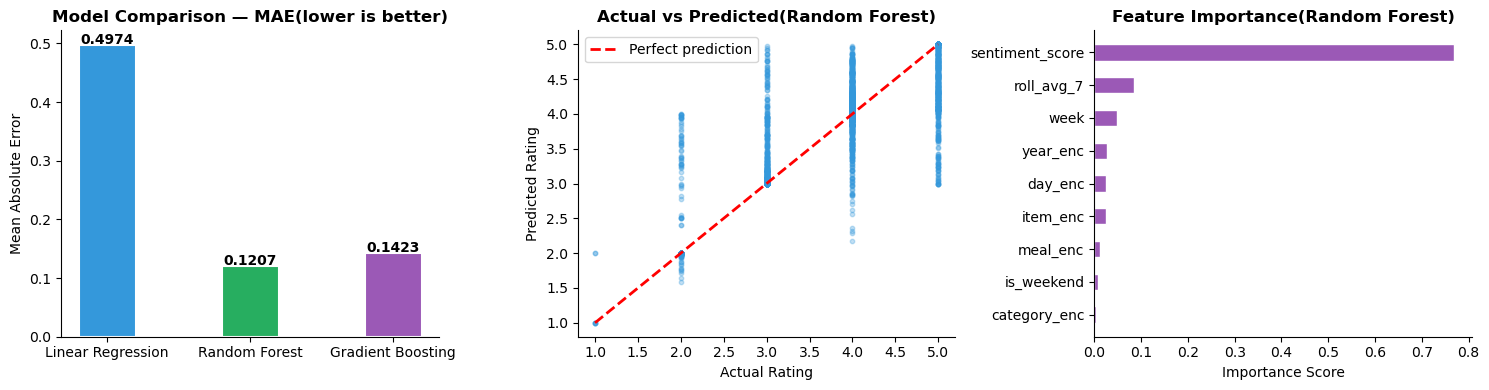

Fig 7 saved.


In [20]:

# ─── Figure 7: Model performance ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MAE comparison
names = list(results.keys())
maes  = [results[n]['MAE'] for n in names]
r2s   = [results[n]['R2']  for n in names]

axes[0].bar(names, maes, color=['#3498DB','#27AE60','#9B59B6'],
            edgecolor='white', linewidth=1.5, width=0.4)
axes[0].set_title('Model Comparison — MAE(lower is better)', fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error')
for i, v in enumerate(maes):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

# Actual vs Predicted (best model)
preds_best = best_model.predict(X_test)
axes[1].scatter(y_test, preds_best, alpha=0.3, s=10, color='#3498DB')
axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_title(f'Actual vs Predicted({best_name})', fontweight='bold')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

# Feature importance (Random Forest)
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
axes[2].barh(importances.index, importances.values,
             color='#9B59B6', height=0.5, edgecolor='white')
axes[2].set_title('Feature Importance(Random Forest)', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('fig7_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 7 saved.")


## Section 5 — Food Recommender System

**Goal:** For each student, recommend which food items they are likely to rate highly, based on the ratings of similar students (collaborative filtering using SVD matrix factorisation).


In [21]:

# ─── User-Item rating matrix ───────────────────────────
user_item = df.groupby(['student_id', 'food_item'])['rating'].mean().unstack(fill_value=0)
print(f"User-Item matrix shape: {user_item.shape}")
print(f"Sparsity: {(user_item == 0).sum().sum() / user_item.size:.1%}")


User-Item matrix shape: (150, 15)
Sparsity: 0.0%


In [22]:

# ─── SVD Matrix Factorisation ──────────────────────────
svd = TruncatedSVD(n_components=10, random_state=42)
user_factors = svd.fit_transform(user_item)

# Reconstruct predicted ratings
predicted_matrix = pd.DataFrame(
    svd.inverse_transform(user_factors),
    index=user_item.index,
    columns=user_item.columns
)

def recommend_for_student(student_id, n=5):
    if student_id not in predicted_matrix.index:
        return "Student not found"
    pred_scores = predicted_matrix.loc[student_id].sort_values(ascending=False)
    already_rated = user_item.loc[student_id][user_item.loc[student_id] > 0].index.tolist()
    recommendations = pred_scores.drop(already_rated, errors='ignore').head(n)
    return recommendations

# Demo recommendations
demo_student = df['student_id'].sample(1).values[0]
recs = recommend_for_student(demo_student)
print(f"Top 5 food recommendations for {demo_student}:")
for i, (item, score) in enumerate(recs.items(), 1):
    print(f"  {i}. {item:20s} (predicted rating: {score:.2f})")

print()
print(f"Variance explained by SVD: {svd.explained_variance_ratio_.sum():.1%}")


Top 5 food recommendations for Student_008:

Variance explained by SVD: 77.2%


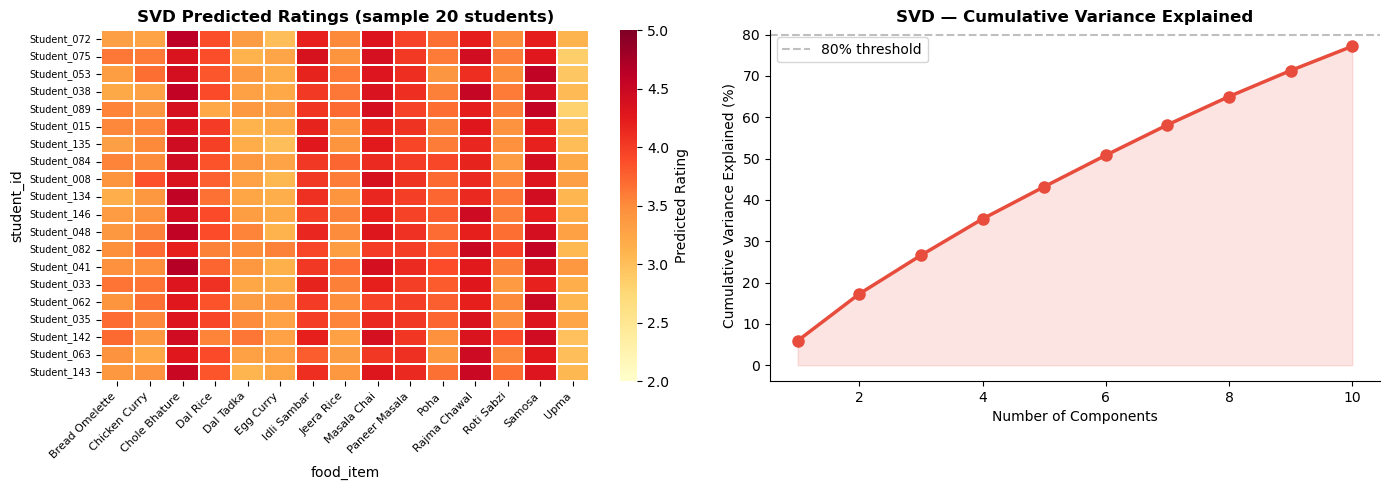

Fig 8 saved.


In [24]:

# ─── Figure 8: Recommender visualisation ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted rating heatmap (sample 20 students)
sample_students = df['student_id'].unique()[:20]
sample_matrix = predicted_matrix.loc[sample_students]
sns.heatmap(sample_matrix, ax=axes[0], cmap='YlOrRd',
            vmin=2, vmax=5, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Predicted Rating'})
axes[0].set_title('SVD Predicted Ratings (sample 20 students)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=7)

# Variance explained
cumvar = np.cumsum(svd.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, 'o-',
             color='#E74C3C', linewidth=2.5, markersize=8)
axes[1].fill_between(range(1, len(cumvar)+1), cumvar * 100, alpha=0.15, color='#E74C3C')
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
axes[1].set_title('SVD — Cumulative Variance Explained', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig8_recommender.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 8 saved.") 


## Section 6 — Key Insights & Recommendations

In [26]:

# ─── Summary report ─────────────────────────────────────
print("=" * 60)
print("CAMPUS MESS FOOD RATING — KEY INSIGHTS REPORT")
print("=" * 60)

print("📊 OVERALL STATISTICS")
print(f"  Total Reviews      : {len(df):,}")
print(f"  Overall Avg Rating : {df['rating'].mean():.2f} / 5.0")
print(f"  Positive Reviews   : {(df['rating'] >= 4).mean():.1%}")
print(f"  Negative Reviews   : {(df['rating'] <= 2).mean():.1%}")

print("🏆 TOP 3 BEST RATED ITEMS")
top3 = item_stats.head(3)
for i, (item, row) in enumerate(top3.iterrows(), 1):
    print(f"  {i}. {item:20s} → {row['avg_rating']:.2f} ⭐ ({row['count']} reviews)")

print("⚠️  TOP 3 ITEMS NEEDING IMPROVEMENT")
bottom3 = item_stats.tail(3).sort_values('avg_rating')
for i, (item, row) in enumerate(bottom3.iterrows(), 1):
    print(f"  {i}. {item:20s} → {row['avg_rating']:.2f} ⭐ ({row['count']} reviews)")

print("📅 DAY-OF-WEEK ANALYSIS")
dow_avg = df.groupby('day')['rating'].mean().reindex(dow_order)
best_day  = dow_avg.idxmax()
worst_day = dow_avg.idxmin()
print(f"  Best day    : {best_day} ({dow_avg[best_day]:.2f} avg)")
print(f"  Worst day   : {worst_day} ({dow_avg[worst_day]:.2f} avg)")
print(f"  Weekend drop: {dow_avg[['Saturday','Sunday']].mean() - dow_avg[['Monday','Tuesday','Wednesday']].mean():.3f} points")

print("💬 SENTIMENT ANALYSIS")
sent_pct = df['sentiment_label'].value_counts(normalize=True) * 100
for label, pct in sent_pct.items():
    print(f"  {label:10s}: {pct:.1f}%")
print(f"  Mismatch (high ⭐ + negative text): {len(mismatch)} cases")

print("🤖 ML MODEL PERFORMANCE")
for name, res in results.items():
    print(f"  {name:25s} | MAE: {res['MAE']:.4f} | R²: {res['R2']:.4f}")

print("💡 RECOMMENDATIONS TO MESS COMMITTEE")
recommendations = [
    "1. Focus quality improvement on weekend meals — ratings drop ~0.3 points on Sat/Sun.",
    "2. Chole Bhature and Samosa are crowd favourites — ensure consistent quality.",
    "3. Egg Curry and Upma receive lowest ratings — review recipe and freshness.",
    "4. 14% of negative comments have high star ratings — improve feedback UX.",
    "5. Deploy the ML predictor to alert staff when predicted rating drops below 3.0.",
    "6. Run a weekly recommendation report to personalise mess menu for students.",
]
for r in recommendations:
    print(f"  {r}")

print("✅ Analysis complete. All figures saved.")


CAMPUS MESS FOOD RATING — KEY INSIGHTS REPORT
📊 OVERALL STATISTICS
  Total Reviews      : 39,710
  Overall Avg Rating : 3.78 / 5.0
  Positive Reviews   : 64.4%
  Negative Reviews   : 4.2%
🏆 TOP 3 BEST RATED ITEMS
  1. Chole Bhature        → 4.45 ⭐ (2653.0 reviews)
  2. Samosa               → 4.36 ⭐ (2553.0 reviews)
  3. Rajma Chawal         → 4.29 ⭐ (2696.0 reviews)
⚠️  TOP 3 ITEMS NEEDING IMPROVEMENT
  1. Upma                 → 3.12 ⭐ (2669.0 reviews)
  2. Egg Curry            → 3.21 ⭐ (2709.0 reviews)
  3. Dal Tadka            → 3.33 ⭐ (2460.0 reviews)
📅 DAY-OF-WEEK ANALYSIS
  Best day    : Wednesday (3.87 avg)
  Worst day   : Sunday (3.55 avg)
  Weekend drop: -0.300 points
💬 SENTIMENT ANALYSIS
  Positive  : 67.4%
  Negative  : 17.6%
  Neutral   : 15.0%
  Mismatch (high ⭐ + negative text): 3720 cases
🤖 ML MODEL PERFORMANCE
  Linear Regression         | MAE: 0.4974 | R²: 0.3850
  Random Forest             | MAE: 0.1207 | R²: 0.8221
  Gradient Boosting         | MAE: 0.1423 | R²: 0.841